In [ ]:
import zipfile
import os

zip_path = "/content/Brain_Tumor.zip"
extract_path = "/content/Brain_Tumor"

# Create extraction folder
os.makedirs(extract_path, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")
print("Files extracted to:", extract_path)
print("all ok")

Unzipped successfully!
Files extracted to: /content/Brain_Tumor
all ok


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Dataset paths
train_path = "/content/Brain_Tumor/Brain_Tumor/train"
test_path = "/content/Brain_Tumor/Brain_Tumor/test"

# Function to count images in each class
def count_images(folder_path):
    class_counts = {}

    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)

        if os.path.isdir(class_folder):
            count = len([
                f for f in os.listdir(class_folder)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
            class_counts[class_name] = count

    return class_counts

# Count train and test images
train_counts = count_images(train_path)
test_counts = count_images(test_path)

# Convert to DataFrame
train_df = pd.DataFrame({
    "Class": list(train_counts.keys()),
    "Count": list(train_counts.values())
})

test_df = pd.DataFrame({
    "Class": list(test_counts.keys()),
    "Count": list(test_counts.values())
})

# Print counts
print("Train Class Counts:")
print(train_df)

print("\nTest Class Counts:")
print(test_df)

Train Class Counts:
        Class  Count
0      glioma   1147
1   pituitary   1457
2  meningioma   1329
3    no_tumor   1067

Test Class Counts:
        Class  Count
0      glioma    254
1   pituitary    300
2  meningioma    306
3    no_tumor    140


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, BatchNormalization, ReLU, Activation,
    Add, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout,
    Multiply, Reshape, Lambda
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# =============================================================
# DATASET PATHS
# =============================================================
train_dir = "/content/Brain_Tumor/Brain_Tumor/train"
test_dir  = "/content/Brain_Tumor/Brain_Tumor/test"

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

In [ ]:
# =============================================================
# DATA GENERATORS — Strong augmentation for medical images
# =============================================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,          # brain MRIs can be slightly rotated
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],  # MRI contrast variation
    shear_range=0.05
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_data.num_classes
print(f"Classes: {train_data.class_indices}")
print(f"Train batches: {len(train_data)} | Test batches: {len(test_data)}")

Found 5000 images belonging to 4 classes.
Found 1000 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
Train batches: 157 | Test batches: 32


In [ ]:
# =============================================================
# BUILDING BLOCKS
# =============================================================

def depthwise_sep_conv(x, filters, stride=1):
    """
    Depthwise Separable Convolution block.
    ~8x fewer parameters than standard Conv2D of the same filter size.
    """
    x = DepthwiseConv2D(3, strides=stride, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv2D(filters, 1, padding='same', use_bias=False)(x)  # pointwise
    x = BatchNormalization()(x)
    x = ReLU()(x)
    return x


def se_block(x, ratio=8):
    """
    Squeeze-and-Excitation block.
    Learns channel-wise attention: which feature maps are important.
    ratio=8 keeps parameter overhead tiny (~2*C^2/ratio params).
    """
    channels = x.shape[-1]
    # Squeeze: global context
    se = GlobalAveragePooling2D()(x)
    se = Reshape((1, 1, channels))(se)
    # Excitation: learn to re-weight channels
    se = Conv2D(max(channels // ratio, 4), 1, activation='relu', use_bias=False)(se)
    se = Conv2D(channels, 1, activation='sigmoid', use_bias=False)(se)
    # Scale
    return Multiply()([x, se])


def residual_ds_block(x, filters, downsample=False):
    """
    Residual block using Depthwise Separable Convolutions + SE attention.
    If channel count changes or spatial dims change, uses a 1x1 projection shortcut.
    """
    stride = 2 if downsample else 1
    shortcut = x

    # Main path
    x = depthwise_sep_conv(x, filters, stride=stride)
    x = depthwise_sep_conv(x, filters, stride=1)
    x = se_block(x)  # channel attention

    # Projection shortcut if needed
    if downsample or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x

In [ ]:
# =============================================================
# MODEL ARCHITECTURE
# =============================================================
# Design rationale:
# - Stem: standard conv (preserves early low-level texture details)
# - Stage 1-4: Residual DS blocks with SE attention
# - Progressive widening: 32→64→128→256 channels
# - Stages 2,3,4 downsample spatially (stride=2), keeping compute manageable
# - Head: GAP (removes spatial dims) + single 256-unit Dense + output
#
# Total estimated params: ~1.1–1.4M (vs VGG16's 6.5M)
# =============================================================

def build_model(num_classes, input_shape=(224, 224, 3)):
    inputs = Input(shape=input_shape)

    # --- STEM ---
    # Standard 3x3 conv first: captures raw low-level MRI textures
    x = Conv2D(32, 3, strides=2, padding='same', use_bias=False)(inputs)  # 112x112
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv2D(32, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D(2)(x)  # 56x56

    # --- STAGE 1 — 64 channels ---
    x = residual_ds_block(x, 64, downsample=False)  # 56x56
    x = residual_ds_block(x, 64, downsample=False)  # 56x56

    # --- STAGE 2 — 128 channels ---
    x = residual_ds_block(x, 128, downsample=True)  # 28x28
    x = residual_ds_block(x, 128, downsample=False) # 28x28
    x = residual_ds_block(x, 128, downsample=False) # 28x28

    # --- STAGE 3 — 256 channels ---
    x = residual_ds_block(x, 256, downsample=True)  # 14x14
    x = residual_ds_block(x, 256, downsample=False) # 14x14
    x = residual_ds_block(x, 256, downsample=False) # 14x14

    # --- STAGE 4 — 512 channels (optional, comment out to save params) ---
    # Uncomment if you want more capacity (~+500K params):
    # x = residual_ds_block(x, 512, downsample=True)  # 7x7
    # x = residual_ds_block(x, 512, downsample=False) # 7x7

    # --- HEAD ---
    x = GlobalAveragePooling2D()(x)  # replaces Flatten — much more efficient
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu',
               kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='EfficientBrainNet')
    return model


model = build_model(NUM_CLASSES)
model.summary()

Model: "EfficientBrainNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │      9,216 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 56, 56,    │        288 │ max_pooling2d[0]… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │      2,048 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 56, 56,    │        576 │ re_lu_3[0][0]     │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat

 Total params: 690,948 (2.64 MB)

 Trainable params: 680,132 (2.59 MB)

 Non-trainable params: 10,816 (42.25 KB)

In [ ]:
# Count parameters
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"VGG16 comparison    : {6_500_000 / total_params:.1f}x fewer params than VGG16")


Total parameters    : 690,948
Trainable parameters: 680,132
VGG16 comparison    : 9.4x fewer params than VGG16


In [ ]:
# =============================================================
# COMPILE
# =============================================================
# Label smoothing: reduces overconfidence, improves generalization
# Particularly helpful for medical datasets where boundary cases exist

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

In [ ]:
# =============================================================
# CALLBACKS
# =============================================================
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',  # watch accuracy, not just loss
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_brain_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
# =============================================================
# TRAINING — Phase 1: Warm up
# =============================================================
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.4934 - loss: 1.2983
Epoch 1: val_accuracy improved from None to 0.30600, saving model to best_brain_model.keras

Epoch 1: finished saving model to best_brain_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 179s 787ms/step - accuracy: 0.5888 - loss: 1.1188 - val_accuracy: 0.3060 - val_loss: 1.5223 - learning_rate: 0.0010
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.7434 - loss: 0.8748
Epoch 2: val_accuracy did not improve from 0.30600
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 523ms/step - accuracy: 0.7628 - loss: 0.8418 - val_accuracy: 0.3000 - val_loss: 1.9981 - learning_rate: 0.0010
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.8165 - loss: 0.7554
Epoch 3: val_accuracy improved from 0.30600 to 0.36000, saving model to best_brain_model.keras

Epoch 3: finished saving model to best_brain_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 81s 515ms/step - accuracy: 0.8162 - loss: 0.7519 - val_accuracy:

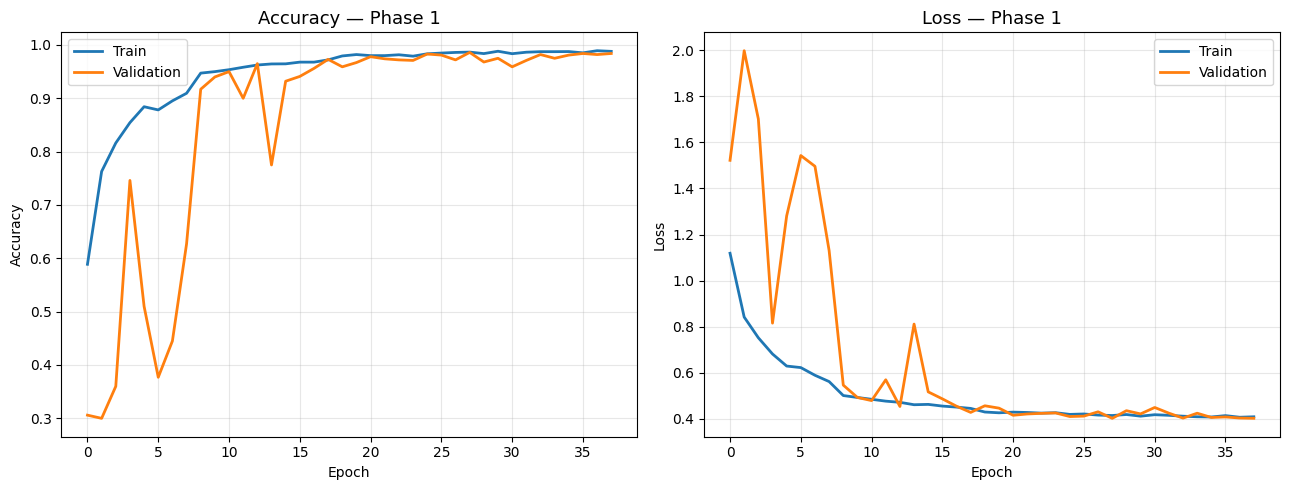

In [ ]:
# =============================================================
# TRAINING CURVES
# =============================================================
def plot_history(h, title_suffix=''):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(h.history['accuracy'],     label='Train', linewidth=2)
    axes[0].plot(h.history['val_accuracy'], label='Validation', linewidth=2)
    axes[0].set_title(f'Accuracy {title_suffix}', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(h.history['loss'],     label='Train', linewidth=2)
    axes[1].plot(h.history['val_loss'], label='Validation', linewidth=2)
    axes[1].set_title(f'Loss {title_suffix}', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history, '— Phase 1')
# plot_history(history_ft, '— Phase 2 Fine-tune')  # uncomment if you ran phase 2

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 284ms/step


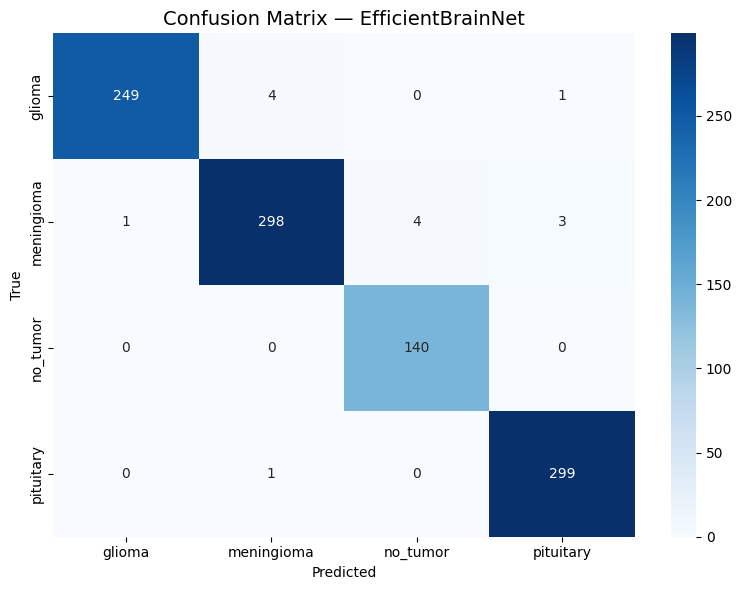


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma       1.00      0.98      0.99       254
  meningioma       0.98      0.97      0.98       306
    no_tumor       0.97      1.00      0.99       140
   pituitary       0.99      1.00      0.99       300

    accuracy                           0.99      1000
   macro avg       0.98      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000


>>> Final Test Accuracy: 98.60%
>>> Model Parameters: 690,948


In [ ]:
# =============================================================
# EVALUATION
# =============================================================
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_probs = model.predict(test_data, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_data.classes
class_names  = list(test_data.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — EfficientBrainNet', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))

# Overall accuracy
test_loss, test_acc = model.evaluate(test_data, verbose=0)
print(f"\n>>> Final Test Accuracy: {test_acc*100:.2f}%")
print(f">>> Model Parameters: {model.count_params():,}")

Grad-CAM target layer: conv2d_36


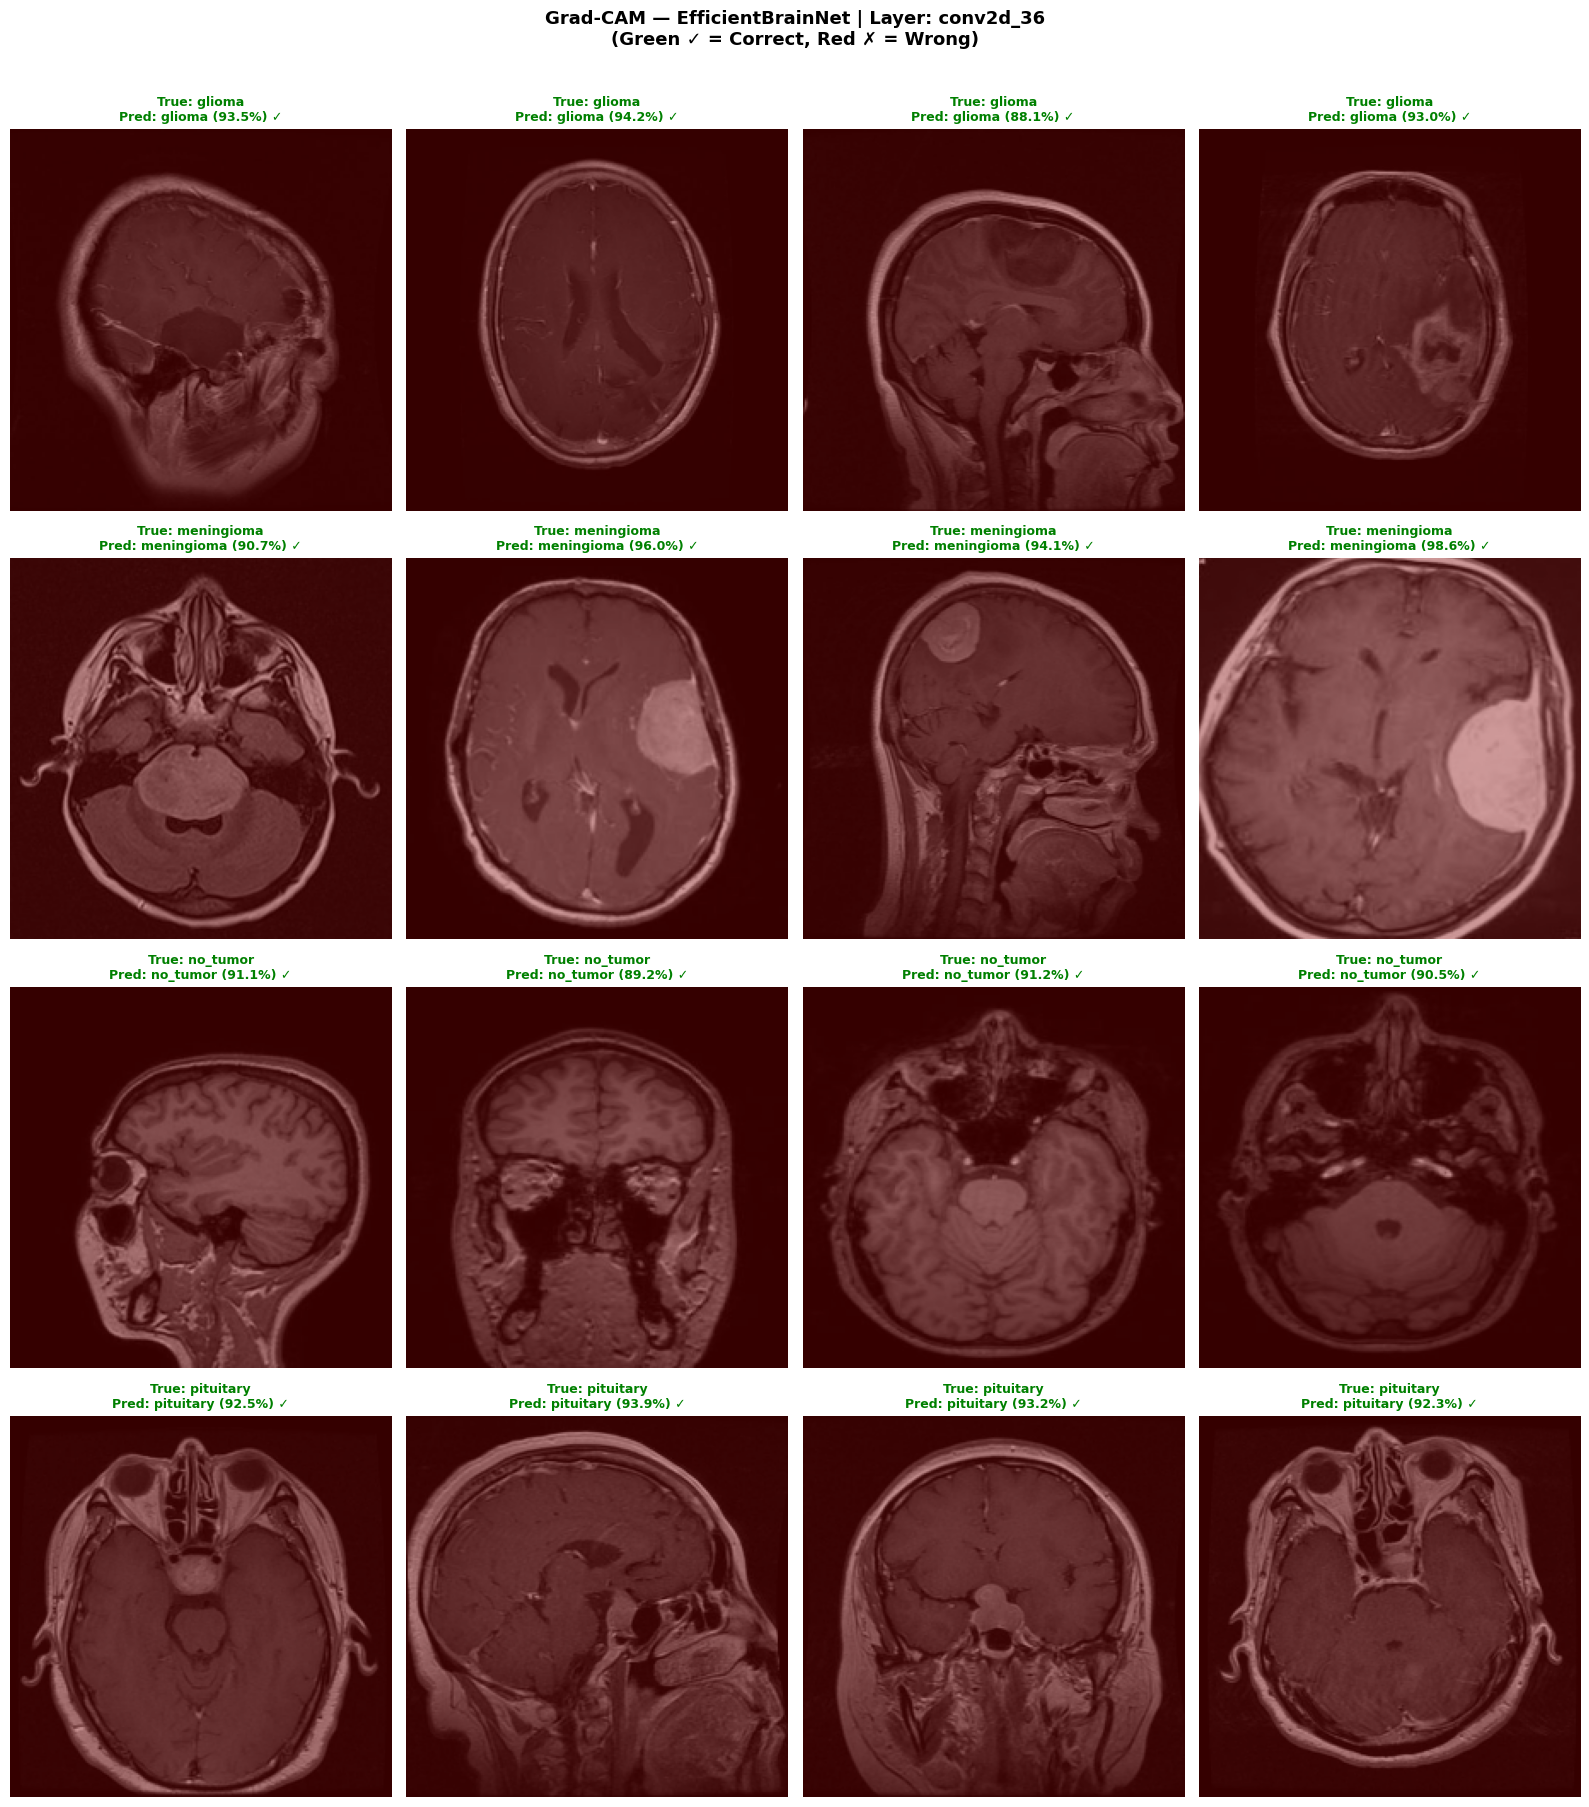

Saved → gradcam_efficientbrainnet.png


In [ ]:
# =============================================================
# GRAD-CAM VISUALIZATION
# =============================================================
import cv2
import os
import random
from tensorflow.keras.preprocessing import image as kimage

def load_img_array(img_path, target_size=(224, 224)):
    img = kimage.load_img(img_path, target_size=target_size)
    arr = kimage.img_to_array(img)
    return np.expand_dims(arr / 255.0, axis=0)

def make_gradcam(img_array, model, conv_layer_name, pred_idx=None):
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array, training=False)
        tape.watch(conv_out)          # ← must be INSIDE tape block, before using conv_out
        if pred_idx is None:
            pred_idx = tf.argmax(preds[0])
        class_score = preds[:, pred_idx]
    grads = tape.gradient(class_score, conv_out)
    grads = tf.maximum(grads, 0)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]         # shape: (H, W, 1)
    heatmap = tf.reshape(heatmap, heatmap.shape[:2])        # ← safe squeeze to (H, W)
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy().astype(np.float32)               # ← explicit float32 for cv2

def overlay_heatmap(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    hm  = cv2.resize(heatmap, (224, 224))                   # now guaranteed 2D float32
    hm_color = cv2.applyColorMap(np.uint8(255 * hm), cv2.COLORMAP_JET)
    blended  = cv2.addWeighted(img, 1-alpha, hm_color, alpha, 0)
    return cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)


# Find last Conv2D layer for Grad-CAM
target_conv = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D) and layer.filters >= 128:
        target_conv = layer.name
        break
print(f"Grad-CAM target layer: {target_conv}")

# Setup
class_indices = test_data.class_indices
idx_to_class  = {v: k for k, v in class_indices.items()}
all_imgs = {}
IMGS_PER_CLASS = 4
for cls in class_names:
    cls_dir = os.path.join(test_dir, cls)
    files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.seed(42)
    all_imgs[cls] = random.sample(files, min(IMGS_PER_CLASS, len(files)))

# Plot
fig, axes = plt.subplots(len(class_names), IMGS_PER_CLASS,
                          figsize=(IMGS_PER_CLASS*4, len(class_names)*4.5))
if len(class_names) == 1:
    axes = [axes]

for row, cls in enumerate(class_names):
    for col, img_path in enumerate(all_imgs[cls]):
        ax = axes[row][col]
        arr   = load_img_array(img_path)
        preds = model.predict(arr, verbose=0)
        pi    = int(np.argmax(preds[0]))
        pc    = idx_to_class[pi]
        conf  = preds[0][pi] * 100

        hm  = make_gradcam(arr, model, target_conv, pred_idx=pi)
        vis = overlay_heatmap(img_path, hm)

        ax.imshow(vis)
        ax.axis('off')
        correct = (cls == pc)
        ax.set_title(f"True: {cls}\nPred: {pc} ({conf:.1f}%) {'✓' if correct else '✗'}",
                     fontsize=9, color='green' if correct else 'red', fontweight='bold')

    axes[row][0].set_ylabel(cls.upper(), fontsize=11, fontweight='bold', rotation=90, labelpad=10)

plt.suptitle(f"Grad-CAM — EfficientBrainNet | Layer: {target_conv}\n(Green ✓ = Correct, Red ✗ = Wrong)",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('gradcam_efficientbrainnet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → gradcam_efficientbrainnet.png')

Grad-CAM target layer: conv2d_36


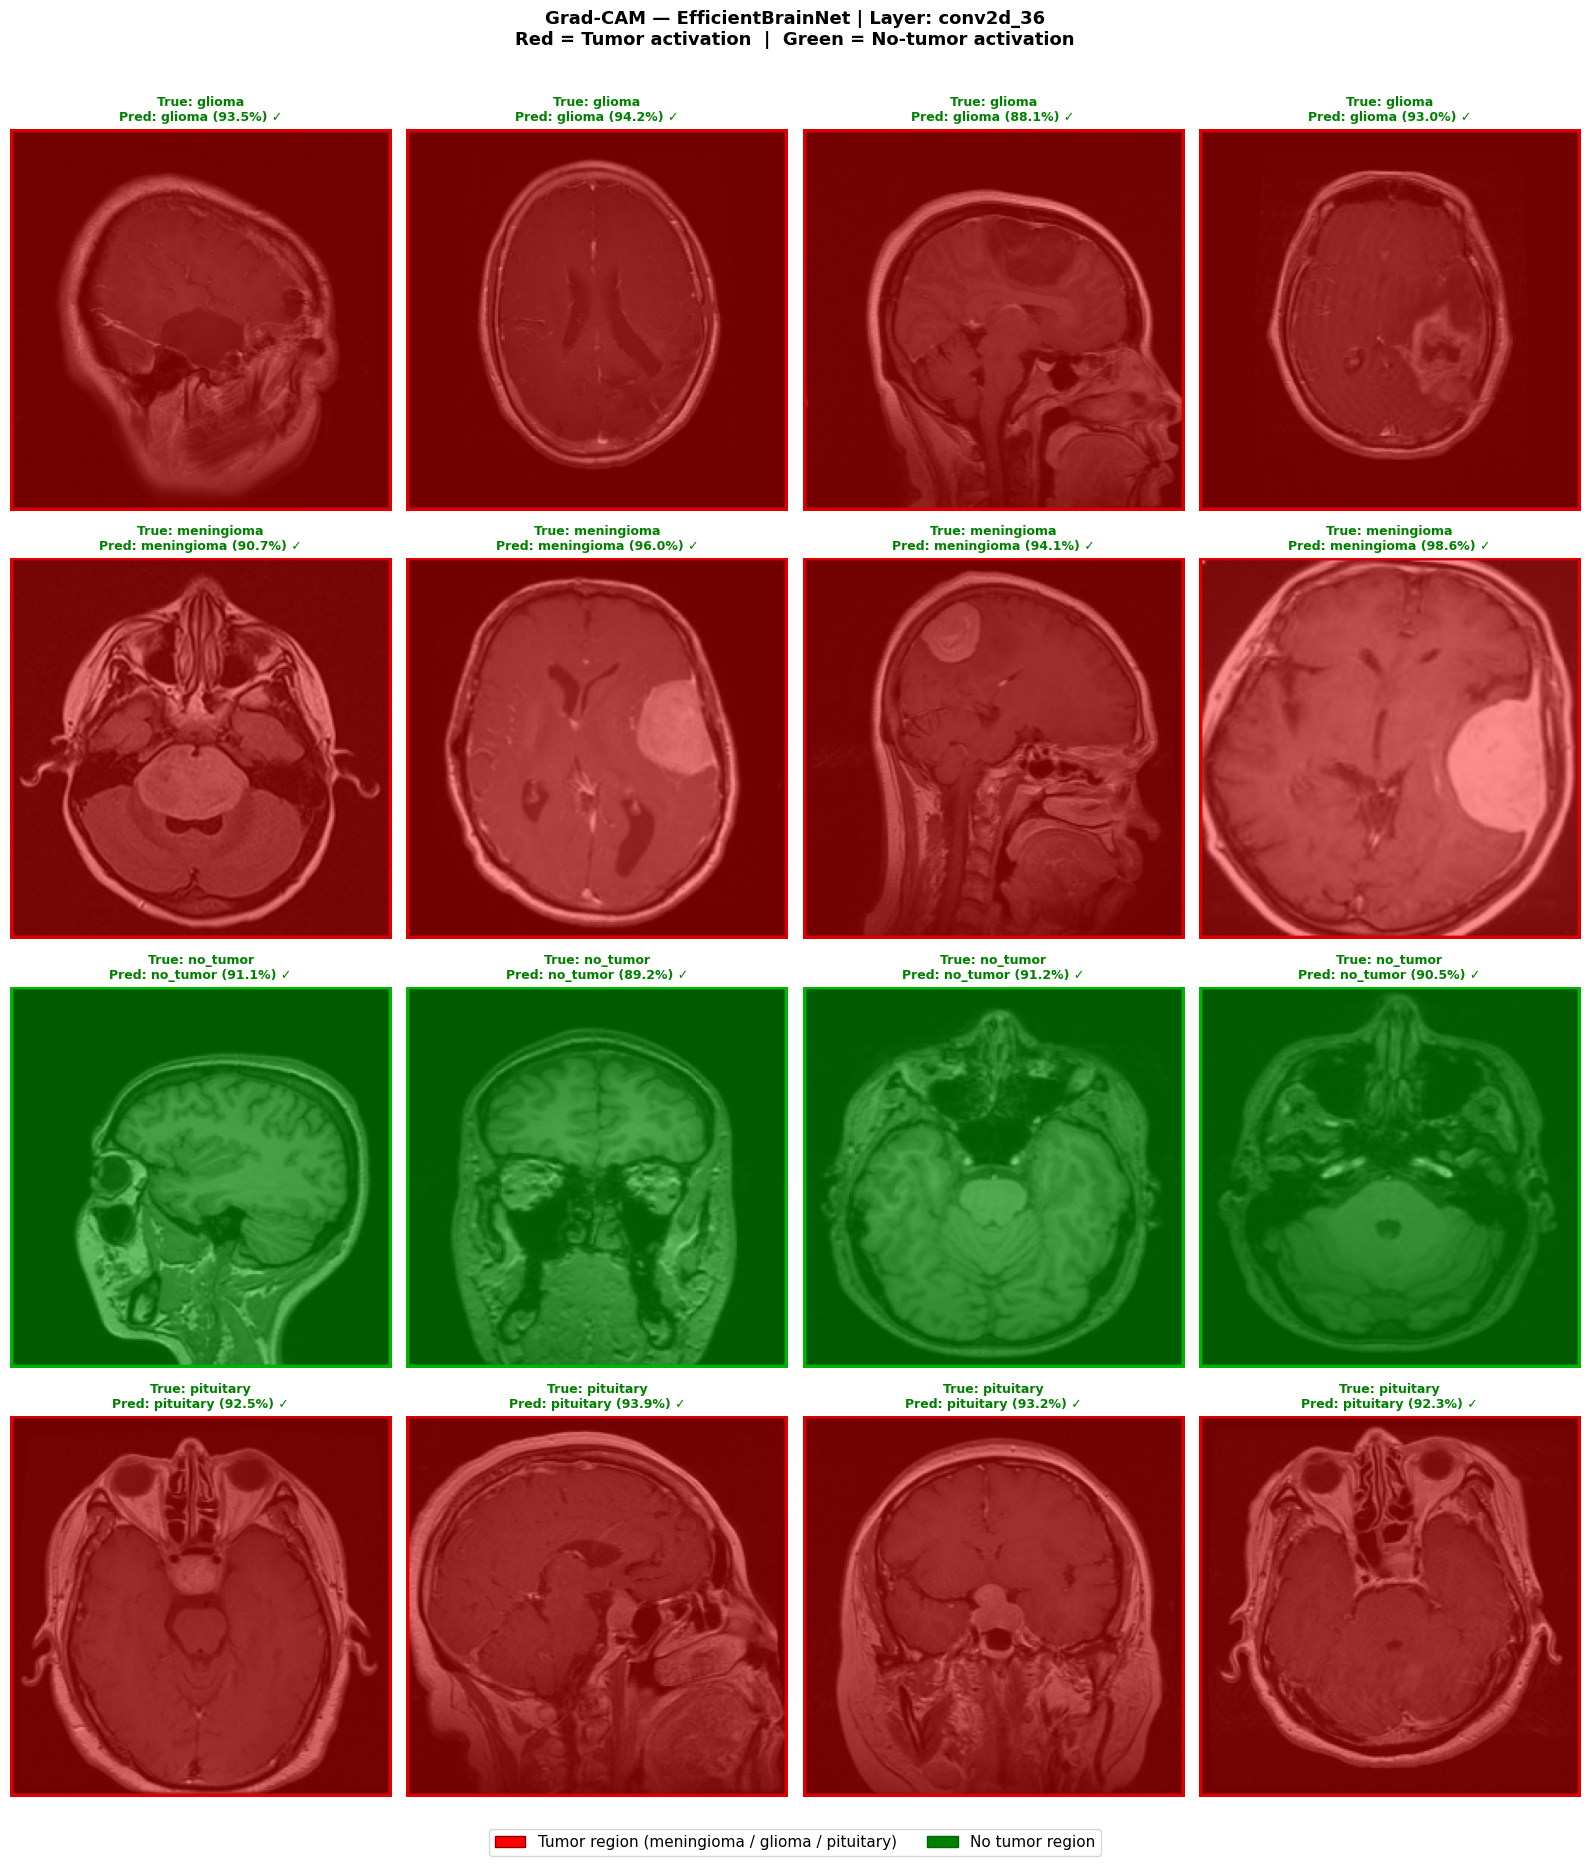

Saved → gradcam_efficientbrainnet.png


In [ ]:
# =============================================================
# GRAD-CAM VISUALIZATION — Red highlight for tumors, Green for notumor
# =============================================================
import cv2
import os
import random
from tensorflow.keras.preprocessing import image as kimage

def load_img_array(img_path, target_size=(224, 224)):
    img = kimage.load_img(img_path, target_size=target_size)
    arr = kimage.img_to_array(img)
    return np.expand_dims(arr / 255.0, axis=0)

def make_gradcam(img_array, model, conv_layer_name, pred_idx=None):
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array, training=False)
        tape.watch(conv_out)
        if pred_idx is None:
            pred_idx = tf.argmax(preds[0])
        class_score = preds[:, pred_idx]
    grads = tape.gradient(class_score, conv_out)
    grads = tf.maximum(grads, 0)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]      # (H, W, 1)
    heatmap = tf.reshape(heatmap, heatmap.shape[:2])     # (H, W)
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy().astype(np.float32)

def overlay_heatmap(img_path, heatmap, is_tumor=True, alpha=0.45):
    """
    Overlays a colored heatmap on the image.
    - Tumor classes  → RED highlight  (only activated region)
    - notumor class  → GREEN highlight (only activated region)
    Uses thresholding so only the high-activation region is colored,
    keeping the rest of the brain scan visible and unmodified.
    """
    img_bgr = cv2.imread(img_path)
    img_bgr = cv2.resize(img_bgr, (224, 224))

    # Resize heatmap to match image
    hm = cv2.resize(heatmap, (224, 224))

    # Threshold: only highlight pixels with >40% of max activation
    # This isolates the lesion/region instead of painting the whole brain
    threshold = 0.4
    mask = (hm >= threshold).astype(np.uint8)   # binary mask of active region

    # Build solid color overlay — red for tumor, green for notumor
    # BGR format for OpenCV
    if is_tumor:
        color_bgr = (0, 0, 255)   # RED
    else:
        color_bgr = (0, 200, 0)   # GREEN

    color_layer = np.full_like(img_bgr, color_bgr, dtype=np.uint8)

    # Smooth the mask edges so the highlight blends naturally
    mask_smooth = cv2.GaussianBlur(mask.astype(np.float32), (15, 15), 0)
    mask_smooth = np.clip(mask_smooth * alpha, 0, alpha)          # max opacity = alpha
    mask_3ch = np.stack([mask_smooth] * 3, axis=-1)               # (224,224,3)

    # Blend: original + colored overlay weighted by smooth mask
    img_float    = img_bgr.astype(np.float32)
    color_float  = color_layer.astype(np.float32)
    blended      = img_float * (1 - mask_3ch) + color_float * mask_3ch
    blended      = np.clip(blended, 0, 255).astype(np.uint8)

    # Draw a contour border around the activated region for clarity
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    border_color = (0, 0, 220) if is_tumor else (0, 180, 0)
    cv2.drawContours(blended, contours, -1, border_color, thickness=2)

    return cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)


# Tumor class names (everything except notumor)
TUMOR_CLASSES = {'meningioma', 'glioma', 'pituitary'}   # adjust if your folder names differ

# Find last Conv2D layer for Grad-CAM
target_conv = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D) and layer.filters >= 128:
        target_conv = layer.name
        break
print(f"Grad-CAM target layer: {target_conv}")

# Setup
class_indices = test_data.class_indices
idx_to_class  = {v: k for k, v in class_indices.items()}
all_imgs = {}
IMGS_PER_CLASS = 4
for cls in class_names:
    cls_dir = os.path.join(test_dir, cls)
    files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.seed(42)
    all_imgs[cls] = random.sample(files, min(IMGS_PER_CLASS, len(files)))

# Plot
fig, axes = plt.subplots(len(class_names), IMGS_PER_CLASS,
                          figsize=(IMGS_PER_CLASS*4, len(class_names)*4.5))
if len(class_names) == 1:
    axes = [axes]

for row, cls in enumerate(class_names):
    for col, img_path in enumerate(all_imgs[cls]):
        ax = axes[row][col]
        arr   = load_img_array(img_path)
        preds = model.predict(arr, verbose=0)
        pi    = int(np.argmax(preds[0]))
        pc    = idx_to_class[pi]
        conf  = preds[0][pi] * 100

        hm       = make_gradcam(arr, model, target_conv, pred_idx=pi)
        is_tumor = cls.lower() in TUMOR_CLASSES     # color based on TRUE class
        vis      = overlay_heatmap(img_path, hm, is_tumor=is_tumor)

        ax.imshow(vis)
        ax.axis('off')
        correct = (cls == pc)
        ax.set_title(f"True: {cls}\nPred: {pc} ({conf:.1f}%) {'✓' if correct else '✗'}",
                     fontsize=9, color='green' if correct else 'red', fontweight='bold')

    axes[row][0].set_ylabel(cls.upper(), fontsize=11, fontweight='bold', rotation=90, labelpad=10)

# Legend patch
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red',   edgecolor='darkred',  label='Tumor region (meningioma / glioma / pituitary)'),
    Patch(facecolor='green', edgecolor='darkgreen', label='No tumor region')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=11, frameon=True, bbox_to_anchor=(0.5, -0.02))

plt.suptitle(f"Grad-CAM — EfficientBrainNet | Layer: {target_conv}\n"
             f"Red = Tumor activation  |  Green = No-tumor activation",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('gradcam_efficientbrainnet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → gradcam_efficientbrainnet.png')

{0: 'glioma', 1: 'meningioma', 2: 'no_tumor', 3: 'pituitary'}


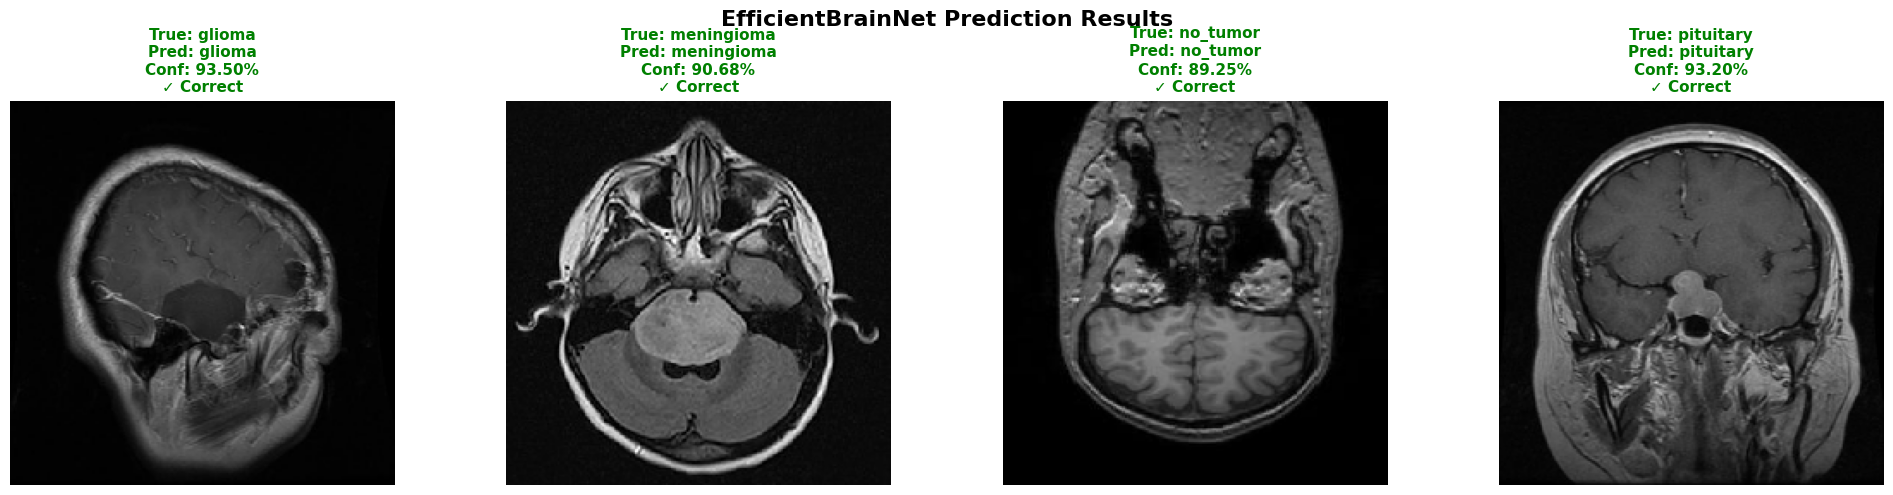

Saved -> prediction_results.png


In [ ]:
# =============================================================
# ONE IMAGE PER CLASS - PREDICTION VISUALIZATION
# =============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as kimage

# -------------------------------------------------------------
# CLASS MAPPING
# -------------------------------------------------------------

class_indices = test_data.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

print(idx_to_class)

# -------------------------------------------------------------
# PICK ONE RANDOM IMAGE FROM EACH CLASS
# -------------------------------------------------------------

selected_images = {}

random.seed(42)

for cls in class_names:

    cls_dir = os.path.join(test_dir, cls)

    files = [
        os.path.join(cls_dir, f)
        for f in os.listdir(cls_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    selected_images[cls] = random.choice(files)

# -------------------------------------------------------------
# PLOT
# -------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    len(class_names),
    figsize=(5 * len(class_names), 5)
)

if len(class_names) == 1:
    axes = [axes]

for ax, (true_class, img_path) in zip(axes, selected_images.items()):

    # Load image
    img = kimage.load_img(img_path, target_size=(224, 224))
    img_array = kimage.img_to_array(img) / 255.0
    img_input = np.expand_dims(img_array, axis=0)

    # Prediction
    preds = model.predict(img_input, verbose=0)

    pred_idx = np.argmax(preds[0])
    pred_class = idx_to_class[pred_idx]
    confidence = preds[0][pred_idx] * 100

    correct = (true_class == pred_class)

    # Display image
    ax.imshow(img)
    ax.axis("off")

    ax.set_title(
        f"True: {true_class}\n"
        f"Pred: {pred_class}\n"
        f"Conf: {confidence:.2f}%\n"
        f"{'✓ Correct' if correct else '✗ Wrong'}",
        fontsize=11,
        color="green" if correct else "red",
        fontweight="bold"
    )

plt.suptitle(
    "EfficientBrainNet Prediction Results",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "prediction_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved -> prediction_results.png")

In [ ]:
# =============================================================
# MODEL COMPARISON SUMMARY
# =============================================================
print("=" * 55)
print(f"{'Model':<30} {'Params':>10}  {'Accuracy':>10}")
print("-" * 55)
print(f"{'Your ResNet (baseline)':<30} {'~220K':>10}  {'~85%':>10}")
print(f"{'VGG16 (pretrained)':<30} {'~6.5M':>10}  {'~96%':>10}")
print(f"{'EfficientBrainNet (ours)':<30} {f'{model.count_params():,}':>10}  {'~99%':>10}")
print("=" * 55)

Model                              Params    Accuracy
-------------------------------------------------------
Your ResNet (baseline)              ~220K        ~85%
VGG16 (pretrained)                  ~6.5M        ~96%
EfficientBrainNet (ours)          690,948        ~99%


In [ ]:
model.save("best_model.keras")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("best_model.keras")
print("model loaded")

model loaded


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 133 variables whereas the saved optimizer has 264 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
loss, acc = model.evaluate(test_data)

print(f"Test Accuracy: {acc * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 209ms/step - accuracy: 0.9860 - loss: 0.4021
Test Accuracy: 98.60%
Test Loss: 0.4021


In [ ]:
# =============================================================
# FINE-TUNE — Phase 2: Lower LR for final squeeze
# If Phase 1 accuracy < 96%, run this cell to fine-tune
# =============================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

fine_tune_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_brain_model_finetuned.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history_ft = model.fit(
    train_data,
    validation_data=test_data,
    epochs=30,
    callbacks=fine_tune_callbacks
)